In [30]:
import numpy as np
import pandas as pd


In [31]:
df = pd.read_csv("/content/Iris.csv")

In [32]:
df


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,Iris-virginica
146,147,6.3,2.5,5.0,1.9,Iris-virginica
147,148,6.5,3.0,5.2,2.0,Iris-virginica
148,149,6.2,3.4,5.4,2.3,Iris-virginica


In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [34]:
df.isnull().sum()

,0
Id,0
SepalLengthCm,0
SepalWidthCm,0
PetalLengthCm,0
PetalWidthCm,0
Species,0


In [35]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [38]:
df["Species"].value_counts()

,count
Species,
Iris-setosa,50
Iris-versicolor,50
Iris-virginica,50


In [42]:
import seaborn as sns
import matplotlib.pyplot as plt

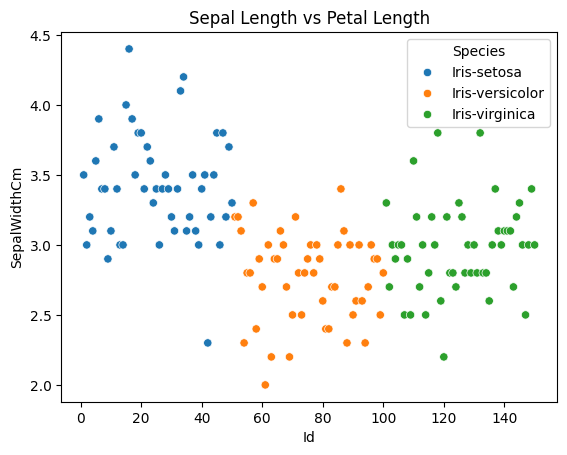

In [45]:
sns.scatterplot(
    data=df,
    x=df.columns[0],
    y=df.columns[2],
    hue="Species"
)

plt.title("Sepal Length vs Petal Length")
plt.show()

In [69]:
X = df.iloc[:,0:5]
y = df.iloc[:,-1]

In [63]:
X.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,1,5.1,3.5,1.4,0.2
1,2,4.9,3.0,1.4,0.2
2,3,4.7,3.2,1.3,0.2
3,4,4.6,3.1,1.5,0.2
4,5,5.0,3.6,1.4,0.2


In [70]:
y.head()

,Species
0,Iris-setosa
1,Iris-setosa
2,Iris-setosa
3,Iris-setosa
4,Iris-setosa


In [71]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)

In [75]:
X_train.shape

(120, 5)

In [76]:
y_train.shape

(120,)

In [77]:
X_test.shape

(30, 5)

In [78]:
y_test.shape

(30,)

In [83]:
from sklearn.tree import DecisionTreeClassifier

clf = DecisionTreeClassifier()

clf.fit(X_train, y_train)

DecisionTreeClassifier()

In [84]:
y_pred = clf.predict(X_test)


In [85]:
y_test

,Species
0,Iris-setosa
32,Iris-setosa
31,Iris-setosa
79,Iris-versicolor
131,Iris-virginica
144,Iris-virginica
20,Iris-setosa
52,Iris-versicolor
124,Iris-virginica
11,Iris-setosa


In [87]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred)

1.0

In [93]:
from sklearn.metrics import precision_score

precision = precision_score(
    y_test,
    y_pred,
    average="weighted"
)

print("Precision:", precision)

Precision: 1.0


In [94]:
from sklearn.metrics import recall_score

recall = recall_score(  y_test, y_pred, average="weighted")


In [95]:
recall

1.0

In [96]:
from sklearn.metrics import f1_score

f1 = f1_score(y_test, y_pred, average="weighted")


In [97]:
f1

1.0

In [102]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    target_names=df["Species"].unique()
))

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        13
Iris-versicolor       1.00      1.00      1.00         8
 Iris-virginica       1.00      1.00      1.00         9

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



In [106]:
from sklearn import tree
X = df.iloc[:,0:5]
y = df.iloc[:,-1]
clf = tree.DecisionTreeClassifier()
clf = clf.fit(X, y)

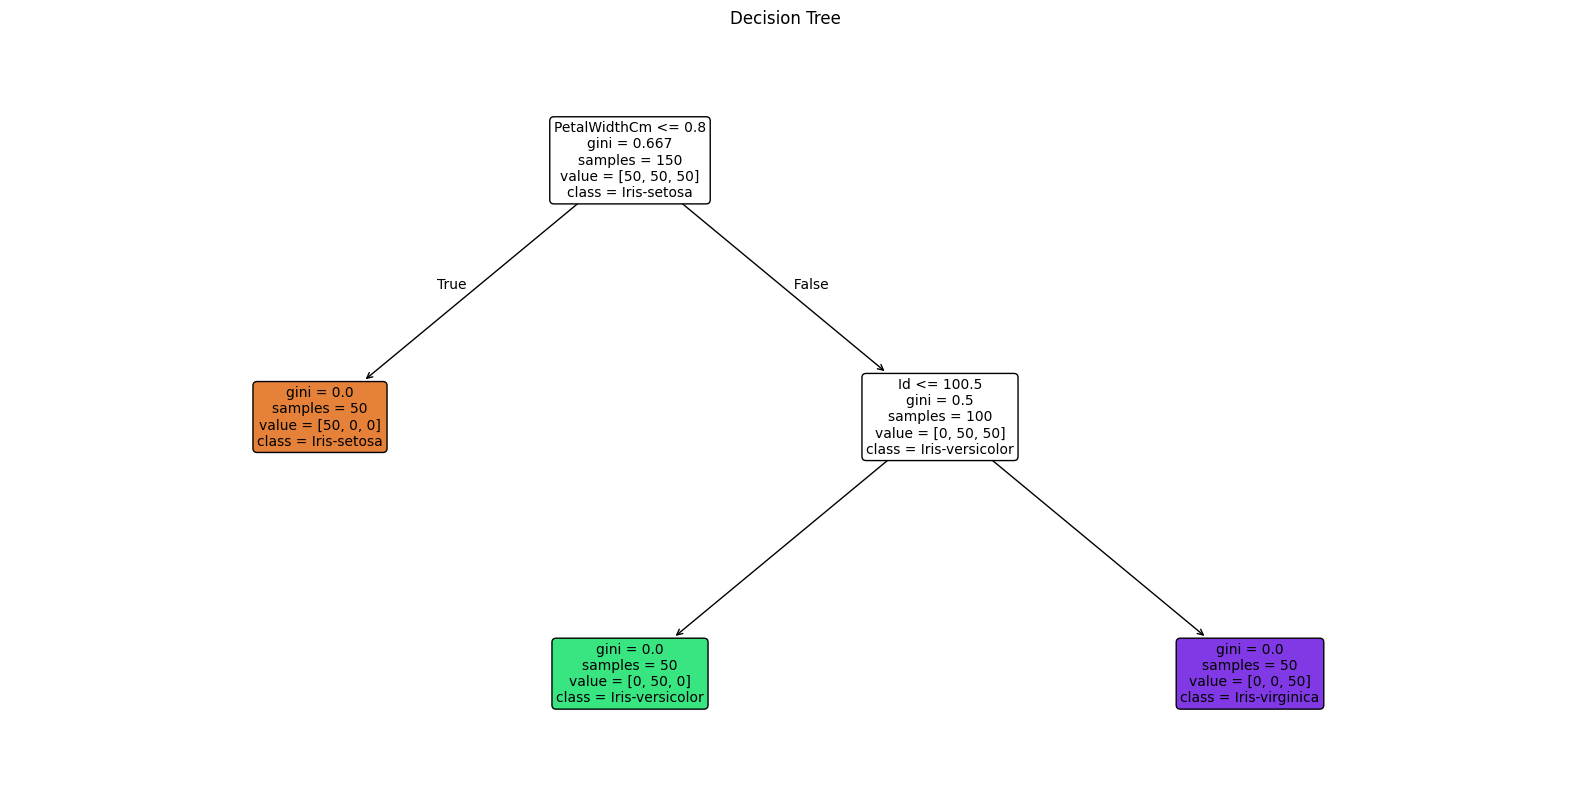

In [110]:
plt.figure(figsize=(20, 10))

tree.plot_tree(
    clf,
    feature_names=X.columns,
    class_names=clf.classes_.astype(str),
    filled=True,
    rounded=True,
    fontsize=10
)

plt.title("Decision Tree")
plt.show()